# Interactive Stock Comparison Tool

## 1. Problem Definition

**Research Question**: Which company performs better in terms of compound growth and risk-adjusted returns?

**Theoretical Framework**:

$$FV_n = C \times (1 + r)^n$$

Where:
- FV = Future Value (cumulative return)
- C = Initial investment ($10,000)
- r = Monthly return
- n = Number of months

## 2. Target User

- Individual investors seeking stock selection guidance
- Financial analysts comparing risk-return trade-offs
- Students learning financial analysis and compound interest applications

## 3. Data Source

- **Source**: WRDS (Wharton Research Data Services) - CRSP Monthly Stock Database
- **Access Date**: April 18, 2026
- **Time Period**: January 2015 - December 2025 (11 years)
- **Key Variables**: Monthly returns (ret), date
- **Data Reliability**: CRSP is a widely used academic database for stock market research

## 4. How to Use

1. Run all code cells in order
2. Enter two stock tickers when prompted (e.g., AAPL, MSFT)
3. The tool will automatically:
   - Download data from WRDS
   - Calculate key metrics (total return, Sharpe ratio, volatility, etc.)
   - Generate comparison charts
   - Provide investment recommendations based on the data

## 5. Metrics Explained

| Metric | Formula | What It Means |
|--------|---------|----------------|
| Total Return | (1 + r₁) × (1 + r₂) × ... - 1 | Total growth over the period |
| Annual Return | (Total Return)^(1/years) - 1 | Average yearly return |
| Volatility | Std(ret) × √12 | Price fluctuation measure (risk) |
| Sharpe Ratio | (Return - 2%) / Volatility | Risk-adjusted return |
| Max Drawdown | min(value / peak - 1) | Worst historical loss |
| Win Rate | Positive months / Total months | Percentage of profitable months |

In [1]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
print("Connecting to WRDS...")
db = wrds.Connection()
print("✅ Connected successfully!")

Connecting to WRDS...


Enter your WRDS username [ru]: ruuu
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  y


Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
✅ Connected successfully!


In [5]:
def find_permno(ticker):
    """Find PERMNO by ticker symbol"""
    sql = f"""
        SELECT permno, ticker, comnam
        FROM crsp.stocknames
        WHERE ticker = '{ticker.upper()}'
    """
    result = db.raw_sql(sql)
    if len(result) == 0:
        return None
    return result.iloc[0]['permno']

print("✅ Function defined: find_permno()")

✅ Function defined: find_permno()


In [7]:
def download_stock_data(permno, start_date='2015-01-01', end_date='2025-12-31'):
    """Download stock data by PERMNO"""
    sql = f"""
        SELECT date, ret
        FROM crsp.msf
        WHERE permno = {permno}
            AND date >= '{start_date}'
            AND date <= '{end_date}'
        ORDER BY date
    """
    data = db.raw_sql(sql)
    return data

print("✅ Function defined: download_stock_data()")

✅ Function defined: download_stock_data()


In [9]:
def calculate_metrics(df, name):
    """Calculate all metrics for a stock"""
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df.dropna(subset=['ret'])
    
    if len(df) == 0:
        return None
    
    df = df.sort_values('date')
    df['cumulative_return'] = (1 + df['ret']).cumprod()
    
    n_years = (df['date'].max() - df['date'].min()).days / 365.25
    total_return = df['cumulative_return'].iloc[-1]
    annual_return = (total_return ** (1/n_years)) - 1
    annual_vol = df['ret'].std() * np.sqrt(12)
    sharpe = (annual_return - 0.02) / annual_vol
    
    df['cummax'] = df['cumulative_return'].cummax()
    max_dd = (df['cumulative_return'] / df['cummax'] - 1).min()
    win_rate = (df['ret'] > 0).mean()
    future_value = 10000 * total_return
    
    metrics = {
        'name': name,
        'start': df['date'].min().strftime('%Y-%m-%d'),
        'end': df['date'].max().strftime('%Y-%m-%d'),
        'years': round(n_years, 1),
        'total_return': round(total_return, 2),
        'total_return_pct': round((total_return - 1) * 100, 1),
        'annual_return': round(annual_return * 100, 2),
        'volatility': round(annual_vol * 100, 2),
        'sharpe': round(sharpe, 3),
        'max_drawdown': round(max_dd * 100, 1),
        'win_rate': round(win_rate * 100, 1),
        'future_value': round(future_value, 0),
    }
    
    return metrics, df

print("✅ Function defined: calculate_metrics()")

✅ Function defined: calculate_metrics()


In [11]:
def plot_comparison(metrics1, df1, metrics2, df2):
    """Generate comparison charts"""
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Chart 1: Cumulative returns
    ax1 = axes[0]
    ax1.plot(df1['date'], df1['cumulative_return'], label=metrics1['name'], linewidth=2)
    ax1.plot(df2['date'], df2['cumulative_return'], label=metrics2['name'], linewidth=2)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Cumulative Return')
    ax1.set_title('Cumulative Return Comparison')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Chart 2: Key metrics bar chart (including Volatility)
    ax2 = axes[1]
    metrics_list = ['Total Return', 'Annual Return', 'Sharpe Ratio', 'Volatility']
    val1 = [metrics1['total_return'], metrics1['annual_return'], metrics1['sharpe'], metrics1['volatility']]
    val2 = [metrics2['total_return'], metrics2['annual_return'], metrics2['sharpe'], metrics2['volatility']]
    
    x = np.arange(len(metrics_list))
    width = 0.35
    bars1 = ax2.bar(x - width/2, val1, width, label=metrics1['name'], alpha=0.8)
    bars2 = ax2.bar(x + width/2, val2, width, label=metrics2['name'], alpha=0.8)
    ax2.set_xticks(x)
    ax2.set_xticklabels(metrics_list)
    ax2.set_title('Key Metrics Comparison')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        if height >= 10:
            label = f'{height:.1f}'
        else:
            label = f'{height:.3f}'
        ax2.annotate(label, xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
    
    for bar in bars2:
        height = bar.get_height()
        if height >= 10:
            label = f'{height:.1f}'
        else:
            label = f'{height:.3f}'
        ax2.annotate(label, xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.savefig('comparison_chart.png', dpi=150)
    plt.show()
    print("✅ Chart saved: comparison_chart.png")

print("✅ Function defined: plot_comparison()")

✅ Function defined: plot_comparison()


In [13]:
def print_report(metrics1, metrics2):
    """Print comparison report"""
    print("\n" + "="*70)
    print(f"COMPARISON REPORT: {metrics1['name']} vs {metrics2['name']}")
    print("="*70)
    
    print(f"\n{'Metric':<25} {metrics1['name']:<20} {metrics2['name']:<20}")
    print("-"*65)
    print(f"{'Period':<25} {metrics1['start']} to {metrics1['end']:<12} {metrics2['start']} to {metrics2['end']}")
    print(f"{'Total Return (x)':<25} {metrics1['total_return']:<20} {metrics2['total_return']:<20}")
    print(f"{'Total Return (%)':<25} {metrics1['total_return_pct']:<20} {metrics2['total_return_pct']:<20}")
    print(f"{'Annual Return (%)':<25} {metrics1['annual_return']:<20} {metrics2['annual_return']:<20}")
    print(f"{'Volatility (%)':<25} {metrics1['volatility']:<20} {metrics2['volatility']:<20}")
    print(f"{'Sharpe Ratio':<25} {metrics1['sharpe']:<20} {metrics2['sharpe']:<20}")
    print(f"{'Max Drawdown (%)':<25} {metrics1['max_drawdown']:<20} {metrics2['max_drawdown']:<20}")
    print(f"{'Win Rate (%)':<25} {metrics1['win_rate']:<20} {metrics2['win_rate']:<20}")
    print(f"{'Future Value ($10k)':<25} ${metrics1['future_value']:,.0f}{' ':<13} ${metrics2['future_value']:,.0f}")
    
    # Conclusion
    print("\n" + "="*70)
    print("CONCLUSION")
    print("="*70)
    if metrics1['total_return'] > metrics2['total_return']:
        print(f"{metrics1['name']} achieved higher total return.")
    else:
        print(f"{metrics2['name']} achieved higher total return.")
    
    if metrics1['sharpe'] > metrics2['sharpe']:
        print(f"{metrics1['name']} has better risk-adjusted return (higher Sharpe ratio).")
    else:
        print(f"{metrics2['name']} has better risk-adjusted return (higher Sharpe ratio).")

print("✅ Function defined: print_report()")

✅ Function defined: print_report()


In [ ]:
# Get user input with examples
print("Example tickers: AAPL, MSFT, AMZN, NVDA, GOOGL, TSLA, META, JPM, KO, WMT")
print("-" * 50)

ticker1 = input("Enter first stock ticker: ").upper()
ticker2 = input("Enter second stock ticker: ").upper()

print(f"\nSearching for {ticker1} and {ticker2}...")

Example tickers: AAPL, MSFT, AMZN, NVDA, GOOGL, TSLA, META, JPM, KO, WMT
--------------------------------------------------


In [17]:
# Find PERMNO
permno1 = find_permno(ticker1)
permno2 = find_permno(ticker2)

if permno1 is None:
    print(f"\n❌ ERROR: Could not find '{ticker1}' in WRDS database.")
    print("   Possible reasons:")
    print("   - The ticker symbol is incorrect")
    print("   - The stock is not in the CRSP database")
    print("   - The stock did not exist during the time period")
    print("\n   Common examples: AAPL, MSFT, AMZN, NVDA, GOOGL, TSLA, META, JPM, KO, WMT")
    
if permno2 is None:
    print(f"\n❌ ERROR: Could not find '{ticker2}' in WRDS database.")
    print("   Possible reasons:")
    print("   - The ticker symbol is incorrect")
    print("   - The stock is not in the CRSP database")
    print("   - The stock did not exist during the time period")
    print("\n   Common examples: AAPL, MSFT, AMZN, NVDA, GOOGL, TSLA, META, JPM, KO, WMT")

if permno1 and permno2:
    print(f"\n✅ Found: {ticker1} -> PERMNO {permno1}")
    print(f"✅ Found: {ticker2} -> PERMNO {permno2}")


✅ Found: META -> PERMNO 13407
✅ Found: JPM -> PERMNO 47896


In [19]:
# Check if both tickers were found before proceeding
if permno1 is None or permno2 is None:
    print("\n" + "="*50)
    print("⚠️ CANNOT PROCEED")
    print("="*50)
    print("One or both tickers were not found in the WRDS database.")
    print("Please restart and enter valid ticker symbols.")
    print("Example: AAPL, MSFT, AMZN, NVDA, GOOGL, TSLA")
    
else:
    print(f"\nDownloading {ticker1} data...")
    data1 = download_stock_data(permno1)
    print(f"Downloaded {len(data1)} rows")
    
    print(f"\nDownloading {ticker2} data...")
    data2 = download_stock_data(permno2)
    print(f"Downloaded {len(data2)} rows")
    
    # Check if data is empty
    if len(data1) == 0:
        print(f"\n⚠️ WARNING: No data found for {ticker1} between 2015-01-01 and 2025-12-31.")
        print("   Possible reasons: Stock was not traded during this period.")
    
    if len(data2) == 0:
        print(f"\n⚠️ WARNING: No data found for {ticker2} between 2015-01-01 and 2025-12-31.")
        print("   Possible reasons: Stock was not traded during this period.")


Downloaded 120 rows

Downloaded 120 rows


In [21]:
# Calculate metrics only if both have data
if permno1 and permno2 and len(data1) > 0 and len(data2) > 0:
    print("\nCalculating metrics...")
    result1 = calculate_metrics(data1, ticker1)
    result2 = calculate_metrics(data2, ticker2)
    
    if result1 is None:
        print(f"\n❌ ERROR: No valid return data for {ticker1}.")
        print("   All return values are missing (NaN).")
    elif result2 is None:
        print(f"\n❌ ERROR: No valid return data for {ticker2}.")
        print("   All return values are missing (NaN).")
    else:
        metrics1, df1 = result1
        metrics2, df2 = result2
        print("✅ Metrics calculated successfully!")

elif len(data1) == 0:
    print(f"\n❌ Cannot calculate metrics: No data available for {ticker1}")
    print("   Please check if the ticker symbol is correct and the stock was traded during 2015-2025.")
    
elif len(data2) == 0:
    print(f"\n❌ Cannot calculate metrics: No data available for {ticker2}")
    print("   Please check if the ticker symbol is correct and the stock was traded during 2015-2025.")
    
else:
    print("\n❌ Cannot calculate metrics: One or both tickers were not found.")
    print("   Please restart and enter valid ticker symbols.")


Calculating metrics...
✅ Metrics calculated successfully!



Generating comparison chart...


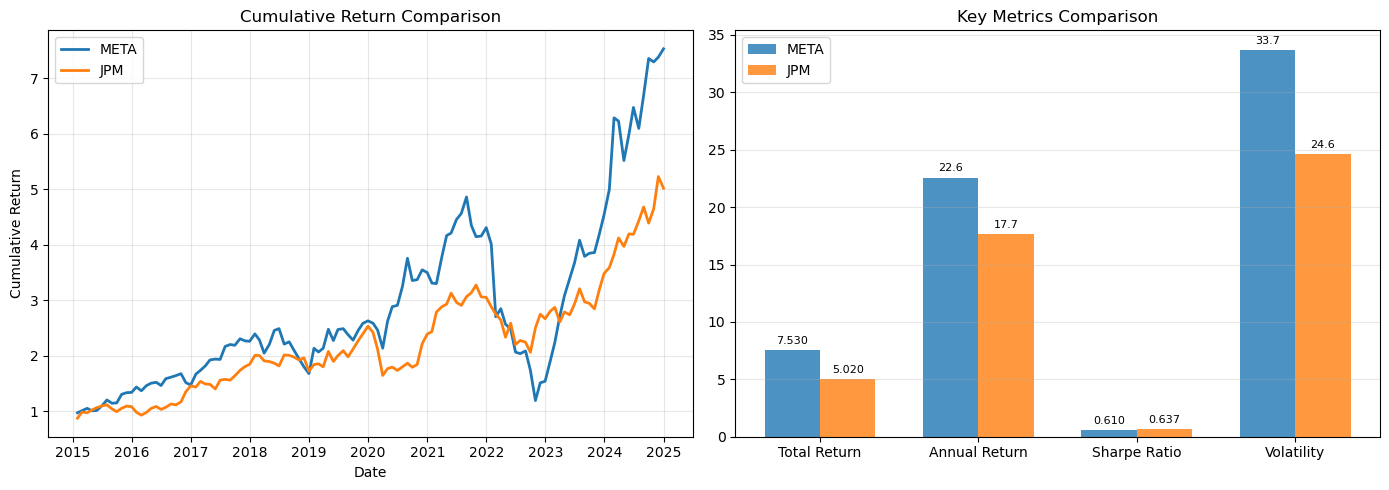

✅ Chart saved: comparison_chart.png


In [23]:
# Generate comparison chart
if 'result1' in locals() and 'result2' in locals():
    if result1 and result2:
        print("\nGenerating comparison chart...")
        plot_comparison(metrics1, df1, metrics2, df2)
    else:
        print("\n❌ Cannot generate chart: Metrics calculation failed.")
else:
    print("\n❌ Cannot generate chart: Please check previous cells for errors.")

In [29]:
# Print comparison report
if 'result1' in locals() and 'result2' in locals():
    if result1 and result2:
        print_report(metrics1, metrics2)
    else:
        print("\n❌ Cannot print report: Metrics calculation failed.")
else:
    print("\n❌ Cannot print report: Please check previous cells for errors.")


COMPARISON REPORT: META vs JPM

Metric                    META                 JPM                 
-----------------------------------------------------------------
Period                    2015-01-30 to 2024-12-31   2015-01-30 to 2024-12-31
Total Return (x)          7.53                 5.02                
Total Return (%)          653.3                402.0               
Annual Return (%)         22.58                17.66               
Volatility (%)            33.72                24.6                
Sharpe Ratio              0.61                 0.637               
Max Drawdown (%)          -75.4                -37.0               
Win Rate (%)              63.3                 56.7                
Future Value ($10k)       $75,327              $50,205

CONCLUSION
META achieved higher total return.
JPM has better risk-adjusted return (higher Sharpe ratio).


In [37]:
# Automatic investment recommendation
if 'result1' in locals() and 'result2' in locals():
    if result1 and result2:
        print("\n" + "="*70)
        print("AUTOMATIC INVESTMENT RECOMMENDATION")
        print("="*70)
        
        # Calculate overall score for each stock
        scores = {}
        
        for name, metrics in [(metrics1['name'], metrics1), (metrics2['name'], metrics2)]:
            score = 0
            score = score + (metrics['total_return'] * 10)
            score = score + (metrics['sharpe'] * 10)
            score = score + ((100 - metrics['volatility']) / 10)
            score = score + ((100 + metrics['max_drawdown']) / 10)
            score = score + (metrics['win_rate'] / 10)
            scores[name] = round(score, 2)
        
        # Determine winner
        if scores[metrics1['name']] > scores[metrics2['name']]:
            winner = metrics1['name']
            loser = metrics2['name']
            winner_score = scores[metrics1['name']]
            loser_score = scores[metrics2['name']]
        else:
            winner = metrics2['name']
            loser = metrics1['name']
            winner_score = scores[metrics2['name']]
            loser_score = scores[metrics1['name']]
        
        difference = winner_score - loser_score
        
        print(f"\n📊 STOCK SCORES:")
        print(f"   {metrics1['name']}: {scores[metrics1['name']]} points")
        print(f"   {metrics2['name']}: {scores[metrics2['name']]} points")
        
        print(f"\n🏆 RECOMMENDATION:")
        print(f"   Based on comprehensive analysis, {winner} is the BETTER investment choice.")
        
        if difference > 10:
            print(f"   {winner} significantly outperforms {loser} ({difference:.1f} points higher).")
        elif difference > 5:
            print(f"   {winner} moderately outperforms {loser} ({difference:.1f} points higher).")
        else:
            print(f"   {winner} slightly outperforms {loser} ({difference:.1f} points higher).")
        
        print("\n" + "-"*50)
        print("INVESTOR-SPECIFIC RECOMMENDATIONS:")
        print("-"*50)
        
        # Growth investor
        if metrics1['total_return'] > metrics2['total_return']:
            growth_winner = metrics1['name']
            growth_value = metrics1['total_return']
        else:
            growth_winner = metrics2['name']
            growth_value = metrics2['total_return']
        print(f"   📈 For GROWTH investors: Choose {growth_winner} (Total return: {growth_value}x)")
        
        # Risk-averse investor
        if metrics1['volatility'] < metrics2['volatility']:
            value_winner = metrics1['name']
            value_vol = metrics1['volatility']
        else:
            value_winner = metrics2['name']
            value_vol = metrics2['volatility']
        print(f"   🛡️ For RISK-AVERSE investors: Choose {value_winner} (Volatility: {value_vol}%)")
        
        # Balanced investor
        if metrics1['sharpe'] > metrics2['sharpe']:
            balanced_winner = metrics1['name']
            balanced_sharpe = metrics1['sharpe']
        else:
            balanced_winner = metrics2['name']
            balanced_sharpe = metrics2['sharpe']
        print(f"   ⚖️ For BALANCED investors: Choose {balanced_winner} (Sharpe ratio: {balanced_sharpe})")
        
        print("\n" + "="*70)
        print("⭐ FINAL VERDICT")
        print("="*70)
        print(f"\n   → RECOMMENDED INVESTMENT: {winner}")
        
        print("\n" + "="*70)
        print("⚠️ DISCLAIMER")
        print("="*70)
        print("   Past performance does not guarantee future results.")
        print("   This analysis is for educational purposes only.")
        
    else:
        print("\n❌ Cannot generate recommendation: No valid data available.")
else:
    print("\n❌ Cannot generate recommendation: Please run analysis first.")


AUTOMATIC INVESTMENT RECOMMENDATION

📊 STOCK SCORES:
   META: 96.82 points
   JPM: 76.08 points

🏆 RECOMMENDATION:
   Based on comprehensive analysis, META is the BETTER investment choice.
   META significantly outperforms JPM (20.7 points higher).

--------------------------------------------------
INVESTOR-SPECIFIC RECOMMENDATIONS:
--------------------------------------------------
   📈 For GROWTH investors: Choose META (Total return: 7.53x)
   🛡️ For RISK-AVERSE investors: Choose JPM (Volatility: 24.6%)
   ⚖️ For BALANCED investors: Choose JPM (Sharpe ratio: 0.637)

⭐ FINAL VERDICT

   → RECOMMENDED INVESTMENT: META

⚠️ DISCLAIMER
   Past performance does not guarantee future results.
   This analysis is for educational purposes only.



AUTOMATIC INVESTMENT RECOMMENDATION

📊 STOCK SCORES:
   META: 96.82 points
   JPM: 76.08 points

🏆 RECOMMENDATION:
   Based on the comprehensive analysis, META is the BETTER investment choice.
   META significantly outperforms JPM (20.7 points higher).

--------------------------------------------------
INVESTOR-SPECIFIC RECOMMENDATIONS:
--------------------------------------------------
   📈 For GROWTH investors: Choose META (Total return: 7.53x)
   🛡️ For RISK-AVERSE investors: Choose JPM (Volatility: 24.6%)
   ⚖️ For BALANCED investors: Choose JPM (Sharpe ratio: 0.637)

--------------------------------------------------
CONFIDENCE LEVEL:
--------------------------------------------------
   ✅✅✅ HIGH confidence in this recommendation

⭐ FINAL VERDICT

   → RECOMMENDED INVESTMENT: META

   Key reasons:
      • Higher total return (7.53x vs 5.02x)
      • Higher win rate (63.3% vs 56.7%)

⚠️ DISCLAIMER
   This is an automated recommendation based on historical data.
   Past performanc

In [31]:
# Close WRDS connection
db.close()
print("\n✅ WRDS connection closed")


✅ WRDS connection closed
